# Data Cleaning Trial 1
### to do list:
- undersampling on Save data to fix imbbalance class: DONE
- drop mislabel data: DONE
- tokenize
- save the: (1) cleaned data text, (2) embbemded data

In [ ]:
# ----import tools----

#data manipulation and visualization
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#text processing
from transformers import AutoTokenizer, AutoModelForSequenceClassification #tokenizer and model for text classification
from sklearn.metrics.pairwise import cosine_similarity #for finding similar texts
from cleanlab.classification import CleanLearning # detecting mislabeled data
from sklearn.linear_model import LogisticRegression
import numpy as np

# CollumnTransformer and Pipeline for preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#undersampling with sklearn
from sklearn.utils import resample

In [7]:
# LOAD DATA
raw_df = pd.read_csv("../data/raw/phishing_email_dataset.csv")
raw_df.head()

,email_text,is_scam
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",0
1,the other side of * galicismos * * galicismo *...,0
2,re : equistar deal tickets are you still avail...,0
3,\nHello I am your hot lil horny toy.\n I am...,1
4,software at incredibly low prices ( 86 % lower...,1


## Fix Imballance Class Issue

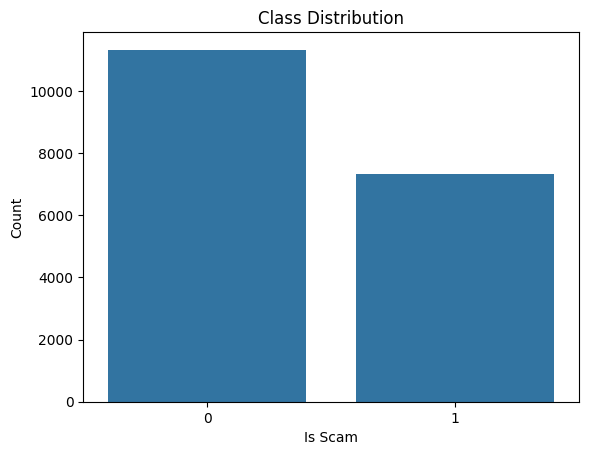

is_scam
0    11322
1     7328
Name: count, dtype: int64

In [13]:
# Visualize class distribution
def plot_class_distribution(df):
    sns.countplot(x="is_scam", data=df)
    plt.title("Class Distribution")
    plt.xlabel("Is Scam")
    plt.ylabel("Count")
    plt.show()
    return(df["is_scam"].value_counts())
    
plot_class_distribution(raw_df)

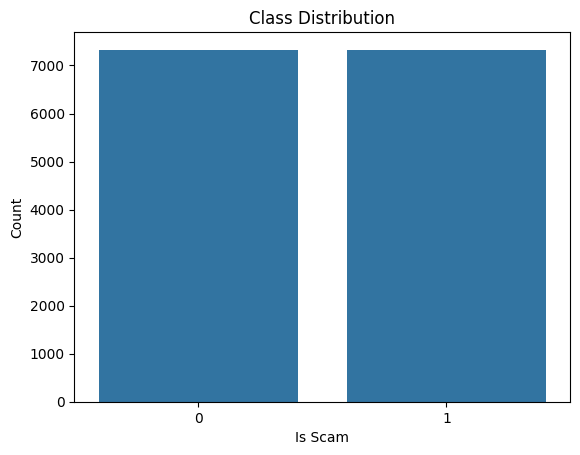

is_scam
0    7328
1    7328
Name: count, dtype: int64

In [14]:
def undersample(df, target_col):
    # Separate majority and minority classes
    majority = df[df[target_col] == 0]
    minority = df[df[target_col] == 1]
    
    # Downsample majority class
    majority_downsampled = resample(majority, 
                                  replace=False,    # sample without replacement
                                  n_samples=len(minority),     # to match minority class
                                  random_state=42)  # reproducible results
    
    # Combine minority class with downsampled majority class
    downsampled_df = pd.concat([majority_downsampled, minority])
    
    return downsampled_df

balanced_df = undersample(raw_df, "is_scam")
plot_class_distribution(balanced_df)

In [17]:
balanced_df = balanced_df.reset_index(drop=True)
balanced_df.head(10)

,email_text,is_scam
0,Eirikur said:\n> This incident is an interesti...,0
1,"hpl noms for june 06 , 2000 ( see attached fil...",0
2,"On Tue, Aug 13, 2002 at 12:48:18AM +0100, wint...",0
3,one more . . . http : / / www . cfo . com / ar...,0
4,use Perl Daily NewsletterIn this issue:\n *...,0
5,enron team 3 question hi melinda ! we need to ...,0
6,"On Thu, 25 Jul 2002 15:25:05 +0200, Matthias S...",0
7,"\nHarlan Feinstein said:> In particular, I was...",0
8,kleberg plant outages in september - - - - - c...,0
9,start date : 1 / 5 / 02 ; hourahead hour : 17 ...,0


In [25]:
# show scam class examples
print("Examples of scam emails:")
print(balanced_df[balanced_df["is_scam"] == 1]["email_text"].head(5))

# -> need to randomise the order of the dataset to avoid any ordering bias
balanced_df = balanced_df.sample(frac=1, random_state=42).reset_index(drop=True)

Examples of scam emails:
7328    \nHello I am your hot lil horny toy.\n    I am...
7329    software at incredibly low prices ( 86 % lower...
7330    entourage , stockmogul newsletter ralph velez ...
7331    we owe you lots of money dear applicant , afte...
7332    make her beg you to give it to her everynight ...
Name: email_text, dtype: object


0    check the lowprices on watches and s . ave on ...
1    cheating women meet married women who want séx...
2    \n    BODY { FONT-SIZE: 12px; FONT-FAMILY: Ari...
3                                                empty
4    drive for free today to unsubscribe from this ...
Name: email_text, dtype: object

# Removing Misleadding labels

In [27]:
def check_mislabeled_data(df, text_col, label_col):
    # Prepare data for cleanlab
    vectorizer = TfidfVectorizer(max_features=5000)
    X = vectorizer.fit_transform(df[text_col].fillna("").tolist())
    y = df[label_col].values
    
    # Train a simple model (Logistic Regression) for cleanlab
    model = LogisticRegression(max_iter=1000)
    clean_learning = CleanLearning(model)
    clean_learning.fit(X, y)
    
    # Get label issues
    label_issues = clean_learning.get_label_issues()
    
    return label_issues

def drop_mislabeled_data(df, label_issues):
    # Drop rows that are suspected to be mislabeled
    clean_df = df[~label_issues["is_label_issue"]].reset_index(drop=True)
    return clean_df

label_issues = check_mislabeled_data(balanced_df, "email_text", "is_scam")
label_issues.head()

,is_label_issue,label_quality,given_label,predicted_label,sample_weight
0,False,0.790515,1,1,1.002048
1,False,0.771077,1,1,1.002048
2,False,0.848842,1,1,1.002048
3,False,0.733538,1,1,1.002048
4,False,0.952137,1,1,1.002048


Label Issue Counts:
is_label_issue
False    14637
True        19
dtype: int64


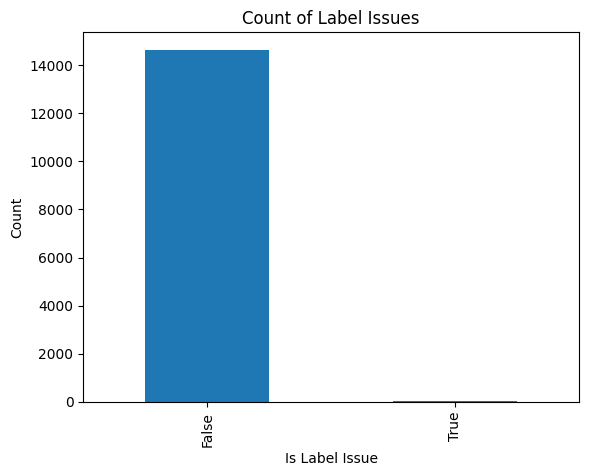

In [30]:
def grouby_label_issues(label_issues):
    # Group by label and count issues
    issue_counts = label_issues.groupby("is_label_issue").size()
    print("Label Issue Counts:")
    print(issue_counts)
    return issue_counts

issue_counts = grouby_label_issues(label_issues)
issue_counts.plot(kind="bar")
plt.title("Count of Label Issues")
plt.xlabel("Is Label Issue")
plt.ylabel("Count")
plt.show()

In [31]:
drop_mislabeled_df = drop_mislabeled_data(balanced_df, label_issues)

In [34]:
drop_mislabeled_df.value_counts("is_scam")

is_scam
1    7324
0    7313
Name: count, dtype: int64

In [36]:
# check null values
print("Null values in each column:")
print(drop_mislabeled_df.isnull().sum())

Null values in each column:
email_text    16
is_scam        0
dtype: int64


In [39]:
#drop rows with null values
drop_mislabeled_df = drop_mislabeled_df.dropna().reset_index(drop=True)
print("Null values after dropping rows with nulls:")
drop_mislabeled_df.isnull().sum()
print("Value counts after dropping nulls:")
drop_mislabeled_df.value_counts("is_scam")

Null values after dropping rows with nulls:
Value counts after dropping nulls:


is_scam
0    7313
1    7308
Name: count, dtype: int64

In [40]:
# save cleaned dataset
drop_mislabeled_df.to_csv("../data/processed/cleaned_phishing_email_dataset.csv", index=False)